# Spotify Data Analysis Project

**Created by**: Urvesh Dabhi

**Tools Used**: Python, Pandas, NumPy, Matplotlib

**Dataset:** Spotify Tracks Dataset (Kaggle)

## Objective
Analyze Spotify track data to uncover insights related to popularity, genres, artists, and musical characteristics.

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

## Data Cleaning 

In [2]:
df = pd.read_csv('dataset.csv', index_col=0)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [3]:
print((df.shape))
print(df.duplicated().sum())
print(df.isnull().sum().sum())

(113549, 20)
0
0


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113549 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113549 non-null  int64  
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 non-null  float64
 15  liveness          113549 non-null  float64
 16  valence           113549 

In [134]:
print("Unique tracks:", df['track_id'].nunique())

Unique tracks: 89740


### Cleaning Summary

- Removed missing values from the dataset.
- Removed duplicate rows.
- Created a duration_min feature from duration_ms.
- Retained genre-specific track entries for genre-level analysis.

### Dataset Overview

The cleaned dataset contains 113,549 track-genre records representing 89,740 unique Spotify tracks and 21 features. The dataset includes information on popularity, genre, artist, duration, danceability, energy, valence, and other audio characteristics.
Some tracks appear multiple times because they are associated with more than one genre.

In [135]:
df['duration_min'] = df['duration_ms'] / 60000

## Track Popularity Analysis 

In [17]:
#top 10 most popular songs 
top_10 = df.sort_values(by='popularity',ascending = False).head(10)
top_10

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,...,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,pop,2.615717
20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,...,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance,2.615717
51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,...,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop,3.315617
68303,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,...,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,latino,2.710617
81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,...,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,pop,2.920633
67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,...,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,latin,2.710617
88410,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,...,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggae,2.710617
30003,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,...,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,edm,2.920633
89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,...,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton,2.710617
20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,...,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,dance,2.920633


In [19]:
top_100 = df.sort_values(by='popularity',ascending = False).head(100)
top_100

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,...,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,pop,2.615717
20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,...,1,0.0864,0.01300,0.000005,0.2660,0.238,131.121,4,dance,2.615717
51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,...,1,0.0440,0.01250,0.033000,0.2300,0.550,128.033,4,hip-hop,3.315617
68303,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,...,0,0.0364,0.58300,0.000002,0.2180,0.850,124.980,4,latino,2.710617
81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,...,0,0.0343,0.00383,0.000007,0.3710,0.304,128.040,4,pop,2.920633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81803,75FEaRjZTKLhTrFGsfMUXR,Kate Bush,Hounds Of Love,Running Up That Hill (A Deal With God),90,298933,False,0.629,0.547,10,...,0,0.0550,0.72000,0.003140,0.0604,0.197,108.375,4,pop,4.982217
51259,38T0tPVZHcPZyhtOcCP7pF,Lil Nas X,STAR WALKIN' (League of Legends Worlds Anthem),STAR WALKIN' (League of Legends Worlds Anthem),90,210575,True,0.637,0.715,2,...,0,0.0455,0.14800,0.000000,0.0892,0.308,141.872,4,hip-hop,3.509583
23002,4zN21mbAuaD0WqtmaTZZeP,James Hype;Miggy Dela Rosa,Ferrari,Ferrari,90,186661,False,0.847,0.690,1,...,0,0.0493,0.01270,0.000060,0.0526,0.692,125.004,4,deep-house,3.111017
51352,1PckUlxKqWQs3RlWXVBLw3,Lizzo,About Damn Time,About Damn Time,89,191822,True,0.836,0.743,10,...,0,0.0656,0.09950,0.000000,0.3350,0.722,108.966,4,hip-hop,3.197033


In [20]:
# considering here most popular = top 100 
unique_artists_intop100 = top_100['artists'].unique()
unique_artists_intop100

array(['Sam Smith;Kim Petras', 'Bizarrap;Quevedo', 'Manuel Turizo',
       'David Guetta;Bebe Rexha', 'Bad Bunny;Chencho Corleone',
       'Bad Bunny', 'OneRepublic', 'Chris Brown', 'Harry Styles',
       'Bad Bunny;Bomba Estéreo', 'Joji', 'KAROL G', 'The Neighbourhood',
       'Beyoncé', 'Tom Odell', 'Arctic Monkeys', 'Nicki Minaj',
       'Charlie Puth;Jung Kook;BTS', 'Rema;Selena Gomez', 'Luar La L',
       'The Weeknd', 'Bad Bunny;Jhayco', 'Drake;21 Savage',
       'Rauw Alejandro;Lyanno;Brray', 'Bad Bunny;Rauw Alejandro',
       'KAROL G;Maldy', 'Kate Bush', 'Bad Bunny;Tony Dize',
       'Shakira;Rauw Alejandro', 'James Hype;Miggy Dela Rosa',
       'The Weeknd;Daft Punk', 'Ruth B.', 'Elley Duhé', 'Doja Cat',
       'The Weeknd;Gesaffelstein', 'Stephen Sanchez', 'Seafret',
       'Beach Weather', 'Lil Nas X', 'Lizzo', 'Billie Eilish;Khalid'],
      dtype=object)

In [21]:
if len(unique_artists_intop100) == 1:
    print(f"Most popular songs are from a single artist: {unique_artists_intop100[0]}")
else:
    print(f"Most popular songs are from {len(unique_artists_intop100)} different artists.")

Most popular songs are from 41 different artists.


### Insight
The Top 100 most popular tracks are distributed across at least 41 unique artist entries, indicating that popularity is spread across many artists rather than being concentrated among only a few.

## Genre Analysis

In [72]:
#average popularity by genres
df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

track_genre
pop-film          59.280280
k-pop             56.963928
chill             53.704705
sad               52.379000
grunge            49.582583
                    ...    
chicago-house     12.333667
detroit-techno    11.183367
latin              8.363636
romance            3.549779
iranian            2.224696
Name: popularity, Length: 114, dtype: float64

In [75]:
# Top 10 most popular genres 
top10_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)
top10_genres

track_genre
pop-film     59.280280
k-pop        56.963928
chill        53.704705
sad          52.379000
grunge       49.582583
indian       49.528529
anime        48.766767
emo          48.128000
pop          47.903323
sertanejo    47.866000
Name: popularity, dtype: float64

### Insight 
Popularity varies substantially across genres, with Pop-film and K-pop averaging more than 50 popularity points, 
while genres such as Iranian and Romance have much lower average popularity scores.

## Artist Analysis 

In [114]:
# top artists by average popularity 
top10_artists = df.groupby('artists')['popularity'].mean().sort_values(ascending= False).head(10)
top10_artists

artists
Sam Smith;Kim Petras          100.0
Bizarrap;Quevedo               99.0
Manuel Turizo                  98.0
Bad Bunny;Chencho Corleone     97.0
Bad Bunny;Bomba Estéreo        94.5
Joji                           94.0
Beyoncé                        93.0
Harry Styles                   92.0
Rema;Selena Gomez              92.0
Drake;21 Savage                91.0
Name: popularity, dtype: float64

### Note 
Artist popularity analysis was performed using artist entries,collaborative tracks are stored as combined artist names in the dataset, so individual artist popularity was not separately analyzed.

## Mood Analysis 

In [131]:
df['mood'] = np.where(df['valence'] >= 0.5,
                      'Positive',
                      'Negative')

df.groupby('mood')['popularity'].mean()

mood
Negative    34.308286
Positive    32.158794
Name: popularity, dtype: float64

### Insight

Negative songs have a slightly higher average popularity score (34.3) than positive songs (32.2). However, the difference is small, suggesting that positive and negative songs are similarly popular overall.

## Song Characteristics Analysis

In [34]:
#Avg song duration 
df['duration_min'].mean()

np.float64(3.801356180738418)

### Insight
The average song duration in the dataset is approximately 3.8 minutes, indicating that most tracks fall within the typical duration range of modern music streaming platforms.

In [35]:
# average danceability,energy and valence of top 100 songs 
top_100[['danceability', 'energy', 'valence']].mean()

danceability    0.701740
energy          0.672510
valence         0.437089
dtype: float64

In [103]:
df[['danceability','energy','valence']].mean()

danceability    0.567031
energy          0.642091
valence         0.474205
dtype: float64

In [130]:
comparison = pd.DataFrame({
    'Top 100 Songs': top_100[['danceability','energy','valence']].mean(),
    'All Songs': df[['danceability','energy','valence']].mean()})

comparison

,Top 100 Songs,All Songs
danceability,0.701740,0.567031
energy,0.672510,0.642091
valence,0.437089,0.474205


### Insight

Compared with the overall dataset, the Top 100 songs are significantly more danceable and slightly more energetic.
However, their average valence is lower than the dataset average.
No strong relationship was observed between popularity and valence. Popular songs tend to be more danceable, but not necessarily happier.

In [36]:
#which genre has highest danceability 
df.groupby('track_genre')['danceability'].mean().sort_values(ascending= False)

track_genre
kids             0.778630
chicago-house    0.766240
reggaeton        0.758521
latino           0.757396
reggae           0.745331
                   ...   
opera            0.313217
iranian          0.300347
black-metal      0.296670
grindcore        0.272077
sleep            0.167923
Name: danceability, Length: 114, dtype: float64

In [105]:
# Top 10 Genres by Average Danceability
top10_danceability =  df.groupby('track_genre')['danceability'].mean().sort_values(ascending= False).head(10)
top10_danceability

track_genre
kids              0.778630
chicago-house     0.766240
reggaeton         0.758521
latino            0.757396
reggae            0.745331
hip-hop           0.735937
dancehall         0.734082
minimal-techno    0.729316
detroit-techno    0.722466
latin             0.721410
Name: danceability, dtype: float64

In [37]:
#which genre has highest energy 
df.groupby('track_genre')['energy'].mean().sort_values(ascending= False)

track_genre
death-metal    0.931468
grindcore      0.924323
metalcore      0.914485
happy          0.910901
hardstyle      0.901173
                 ...   
disney         0.302670
romance        0.298848
ambient        0.237257
new-age        0.213872
classical      0.195193
Name: energy, Length: 114, dtype: float64

In [106]:
#Top 10 Genres by Average Energy
top10_energy = df.groupby('track_genre')['energy'].mean().sort_values(ascending= False).head(10)
top10_energy

track_genre
death-metal      0.931468
grindcore        0.924323
metalcore        0.914485
happy            0.910901
hardstyle        0.901173
drum-and-bass    0.876380
black-metal      0.874721
heavy-metal      0.874152
party            0.871349
j-idol           0.868593
Name: energy, dtype: float64

## Data Visualization

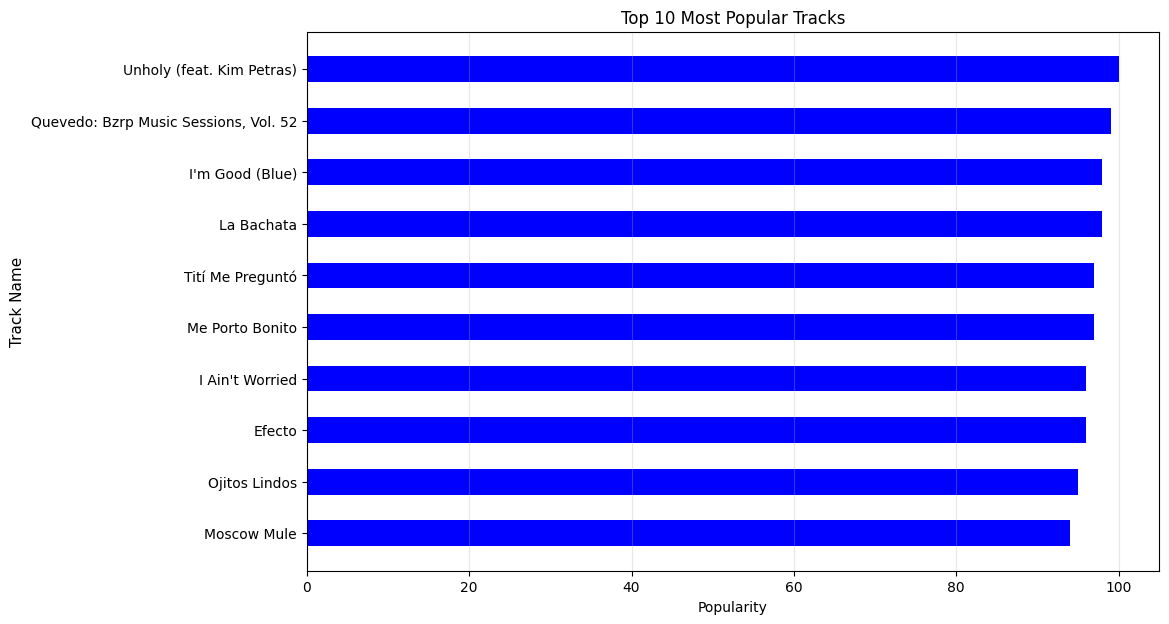

In [128]:
# Top 10 songs by popularity
top_10 = df.drop_duplicates(subset='track_name').sort_values(by='popularity', ascending=False).head(10)

plt.figure(figsize=(11, 7))
plt.barh(top_10['track_name'], top_10['popularity'], color='blue', height=0.5)
plt.xlabel('Popularity', fontsize=10)
plt.ylabel('Track Name', fontsize=11)
plt.title('Top 10 Most Popular Tracks')
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.show()

### Observation

The most popular tracks achieve popularity scores close to 100, indicating extremely high listener engagement.

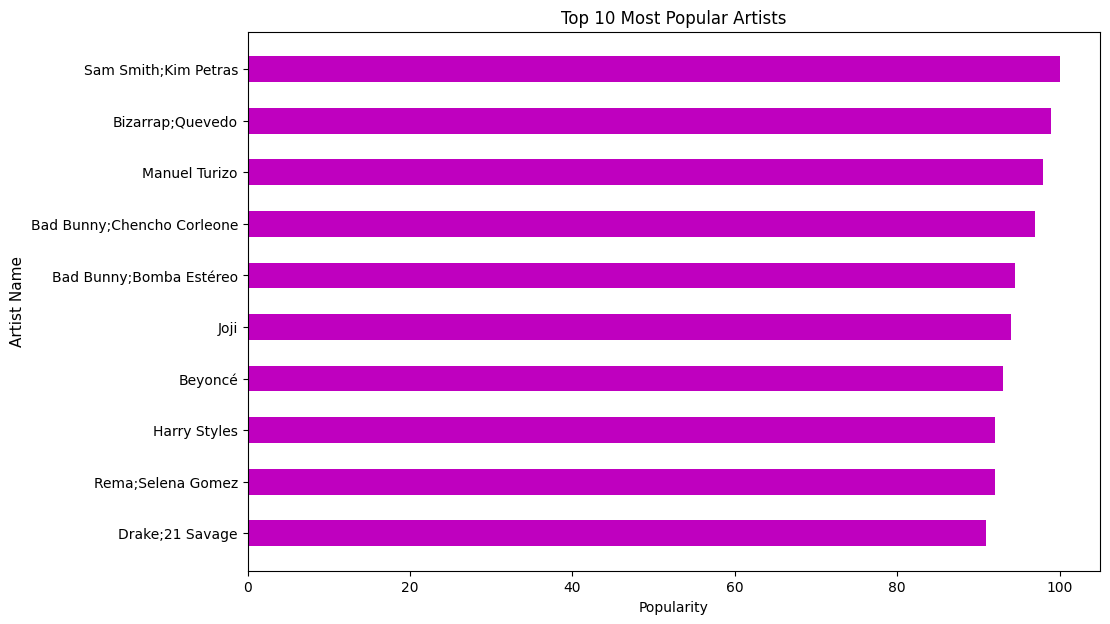

In [129]:
# Top 10 artists by popularity 
top10_artists = df.groupby('artists')['popularity'].mean().sort_values(ascending= False).head(10).reset_index()

top10_artists['artists'] = top10_artists['artists'].str.replace('$', 'S', regex=False)

plt.figure(figsize=(11, 7))
plt.barh(top10_artists['artists'], top10_artists['popularity'], color='m', height=0.5)
plt.xlabel('Popularity', fontsize=10)
plt.ylabel('Artist Name', fontsize=11)
plt.title('Top 10 Most Popular Artists')
plt.gca().invert_yaxis()
plt.show()

### Observation

Several artist entries achieve very high average popularity scores. Collaborative tracks are treated as combined artist entries.

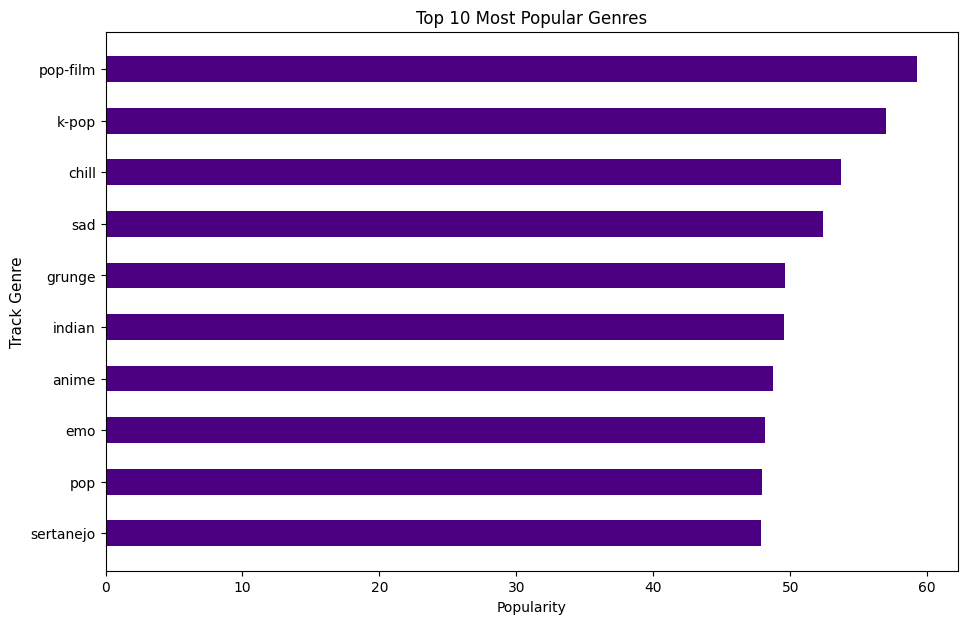

In [117]:
# Top 10 genres by popularity 
top10_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(11, 7))
plt.barh(top10_genres['track_genre'], top10_genres['popularity'], color='indigo', height=0.5)
plt.xlabel('Popularity', fontsize=10)
plt.ylabel('Track Genre', fontsize=11)
plt.title('Top 10 Most Popular Genres')
plt.gca().invert_yaxis()
plt.show()

### Observation

Pop-film and K-pop dominate average popularity rankings among genres.

In [89]:
#Mood Analysis
positive_count = (df['valence'] >= 0.5).sum()
negative_count = (df['valence'] < 0.5).sum()

print("Positive Songs:", positive_count)
print("Negative Songs:", negative_count)

Positive Songs: 51973
Negative Songs: 61576


### Classification Rule 
Songs with valence ≥ 0.5 were classified as positive, while songs with valence < 0.5 were classified as negative.

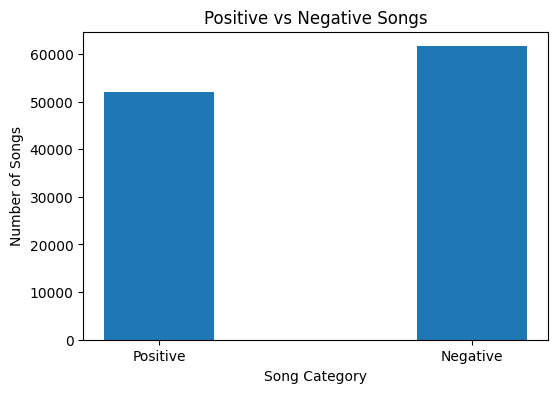

In [101]:
categories = ['Positive', 'Negative']
counts = [positive_count, negative_count]

plt.figure(figsize=(6,4))

plt.bar(categories, counts,width=0.35)

plt.title('Positive vs Negative Songs')
plt.xlabel('Song Category')
plt.ylabel('Number of Songs')

plt.show()

### Observation
Based on valence scores, the dataset contains more negative songs than positive songs.

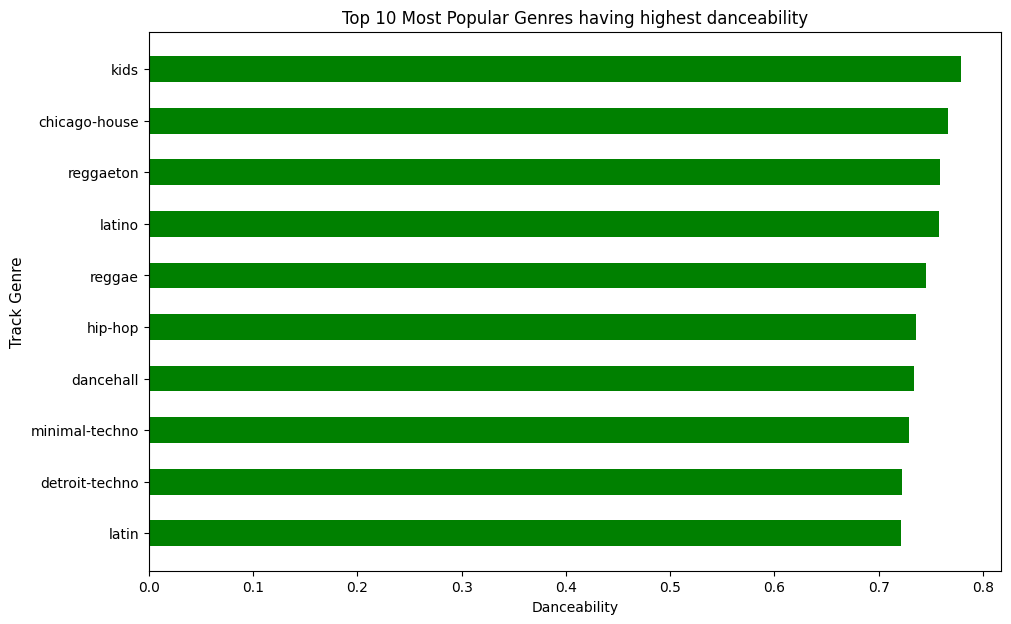

In [136]:
# Top 10 genres by danceability 
top10_danceability =  df.groupby('track_genre')['danceability'].mean().sort_values(ascending= False).head(10).reset_index()

plt.figure(figsize=(11, 7))
plt.barh(top10_danceability['track_genre'], top10_danceability['danceability'], color='green', height=0.5)
plt.xlabel('Danceability', fontsize=10)
plt.ylabel('Track Genre', fontsize=11)
plt.gca().invert_yaxis()
plt.title('Top 10 Most Popular Genres having highest danceability')
plt.show()

### Observation

Danceability varies considerably across genres, with some genres consistently exhibiting higher danceability scores than others.

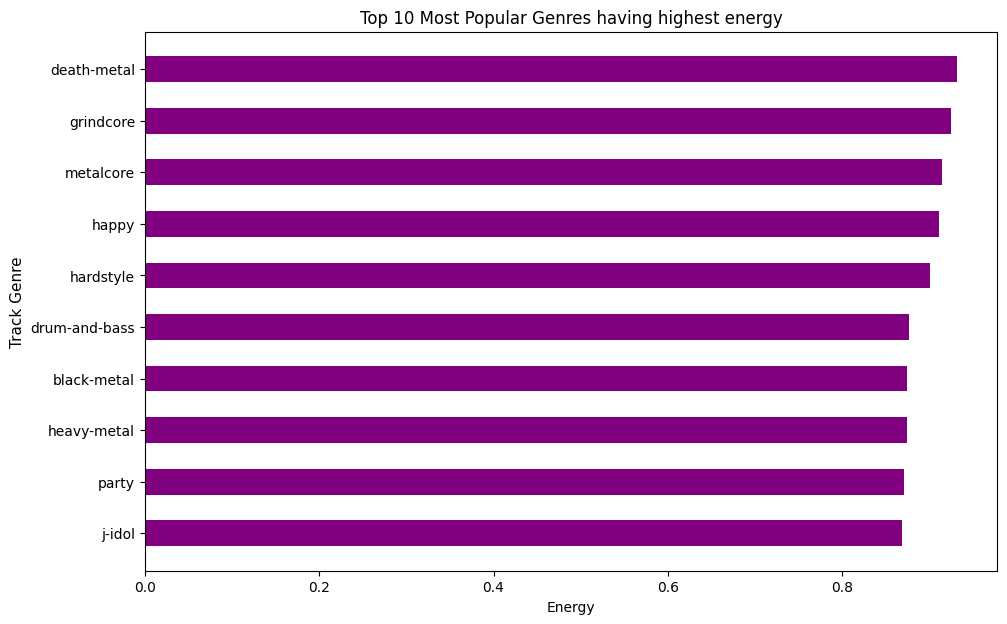

In [138]:
# Top 10 genres by energy
top10_energy = df.groupby('track_genre')['energy'].mean().sort_values(ascending= False).head(10).reset_index()

plt.figure(figsize=(11, 7))
plt.barh(top10_energy['track_genre'], top10_energy['energy'], color='purple', height=0.5)
plt.xlabel('Energy', fontsize=10)
plt.ylabel('Track Genre', fontsize=11)
plt.gca().invert_yaxis()
plt.title('Top 10 Most Popular Genres having highest energy')
plt.show()

### Observation

Certain genres are characterized by substantially higher energy levels, reflecting differences in musical style and intensity.

# Conclusion

## Key Findings

1. The Top 100 most popular tracks are distributed across many artist entries.

2. Pop-film and K-pop have the highest average popularity.

3. Top songs are significantly more danceable than the average song.

4. Popular songs are slightly more energetic than average songs.

5. Positive and negative songs have similar popularity levels, indicating that song mood is not a strong predictor of popularity.

6. Negative songs slightly outnumber positive songs in the dataset when classified using a valence threshold of 0.5.

## Limitations

- Collaborative tracks are stored as combined artist entries.
- Some tracks appear across multiple genres.
- Spotify popularity is a platform-specific popularity metric and not a direct stream count.